## 扒一扒数据集里面代表什么含义？

我们挑选一个 `synthetic` 里面 `panda_synth_train_dr` 的一个图片

./data/dream/synthetic/panda_synth_train_dr/000001.rgb.jpg
./data/dream/synthetic/panda_synth_train_dr/000001.json


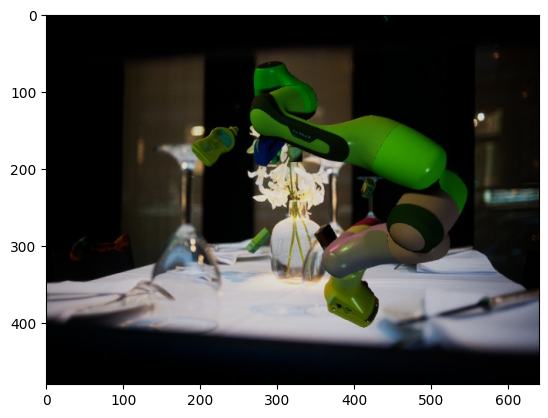

In [1]:
import os
import json
import matplotlib.pyplot as plt
import PIL

base_dir = './data/dream'
choice = 'synthetic/panda_synth_train_dr'
file_name = '000001'

data_dir = os.path.join(base_dir, choice)
img_path = os.path.join(data_dir, file_name + '.rgb.jpg')
annotation_path = os.path.join(data_dir, file_name + '.json')

print(img_path)
print(annotation_path)

img = PIL.Image.open(img_path)
with open(annotation_path, 'r') as f:
    annotations = json.load(f)
plt.imshow(img)


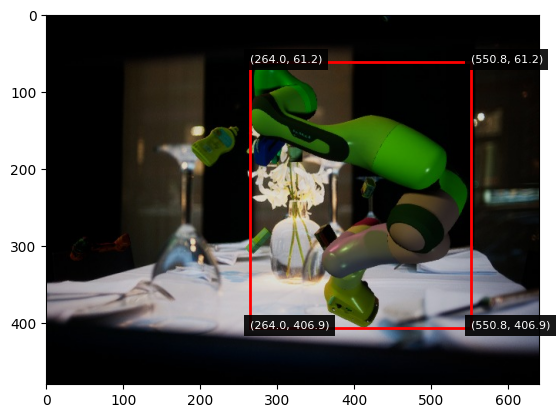

In [2]:
import matplotlib.patches as patches
bbox = annotations['objects'][0]['bounding_box']  # 假设是第一个对象的边界框
min_coords = bbox['min']  # 左下角坐标 [x_min, y_min]
max_coords = bbox['max']  # 右上角坐标 [x_max, y_max]

# 计算边界框的宽度和高度
bbox_width = max_coords[0] - min_coords[0]
bbox_height = max_coords[1] - min_coords[1]

# 创建绘图
fig, ax = plt.subplots(1)
ax.imshow(img)

# 绘制边界框
rect = patches.Rectangle(
    (min_coords[0], min_coords[1]),  # 左下角坐标
    bbox_width,                      # 宽度
    bbox_height,                     # 高度
    linewidth=2,                     # 线宽
    edgecolor='r',                   # 边框颜色（红色）
    facecolor='none'                 # 无填充
)
ax.add_patch(rect)
# 边界框的四个角点坐标
corners = [
    (min_coords[0], min_coords[1]),  # 左下角
    (max_coords[0], min_coords[1]),  # 右下角
    (max_coords[0], max_coords[1]),  # 右上角
    (min_coords[0], max_coords[1])   # 左上角
]

# 在图片上显示四个角点坐标
for i, (x, y) in enumerate(corners):
    ax.text(x, y, f'({x:.1f}, {y:.1f})', color='white', fontsize=8, 
            bbox=dict(facecolor='black', alpha=0.9, edgecolor='none'))  # 白色文字，黑色背景
plt.show()

['panda_joint1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 'panda_joint5', 'panda_joint6', 'panda_joint7', 'panda_finger_joint1']
[[401.0242919921875, 301.0924072265625], [401.0242919921875, 301.09228515625], [525.011474609375, 290.2560119628906], [497.26470947265625, 250.0207977294922], [323.756103515625, 117.26480102539062], [323.7560119628906, 117.26490020751953], [292.739990234375, 105.03459930419922], [297.5671081542969, 173.03480529785156]]


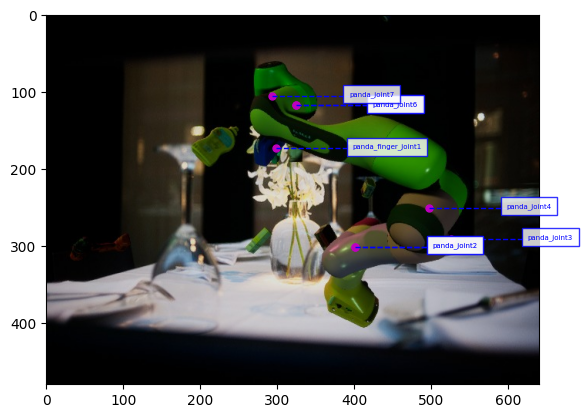

In [3]:
keypoints = annotations['objects'][0]['keypoints']
from lib.dataset.const import KEYPOINT_NAMES, JOINT_NAMES
fig, ax = plt.subplots(1)
ax.imshow(img)
# 绘制每个 projected_location 的蓝色点和 name
# 根据 KEYPOINT_NAMES 提取对应的 3D 点
selected_points = []
selected_names = []
for name in JOINT_NAMES['panda']:
    for kp in keypoints:
        if kp['name'] == name and 'collision' not in kp['name']:
            selected_points.append(kp['projected_location'])  # 提取 projected_location 的坐标
            selected_names.append(name)  # 提取 name
            break

print(selected_names)
print(selected_points)

# 绘制每个 selected_points 的蓝色点和 name
for (x, y), name in zip(selected_points, selected_names):
    # 绘制蓝色点
    ax.plot(x, y, 'mo', markersize=5)  # 'mo' 表示洋红色圆点

    # 设置标注框的偏移量
    offset_x = 100  # 水平偏移量
    offset_y = 0  # 垂直偏移量

    # 标注框的坐标
    text_x = x + offset_x
    text_y = y + offset_y

    # 绘制连接线（从点到标注框）
    ax.plot([x, text_x], [y, text_y], color='blue', linestyle='--', linewidth=1)  # 蓝色虚线

    # 在偏移位置标注 name
    ax.text(text_x, text_y, name, color='blue', fontsize=5, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'))  # 白色背景，蓝色文字，蓝色边框

plt.show()

In [22]:
[x['name'] for x in annotations['objects'][0]['keypoints'] ]

['panda_finger_joint1',
 'panda_rightfinger (collision)',
 'panda_joint1',
 'panda_link2',
 'panda_link3',
 'panda_link4',
 'panda_link5',
 'panda_joint6',
 'panda_link7',
 'panda_link8',
 'panda_leftfinger (collision)',
 'panda_leftfinger',
 'panda_hand (collision)',
 'panda_link1 (collision)',
 'panda_link2 (collision)',
 'panda_link3 (collision)',
 'panda_link4 (collision)',
 'panda_link5 (collision)',
 'panda_link6 (collision)',
 'panda_joint7',
 'panda_hand_joint',
 'panda_rightfinger',
 'panda_link0 (collision)',
 'panda_hand',
 'panda_finger_joint2',
 'panda_link0',
 'panda_link1',
 'panda_joint2',
 'panda_joint3',
 'panda_joint4',
 'panda_joint5',
 'panda_link6',
 'panda_link7 (collision)',
 'panda_joint8']

Selected Names: ['panda_finger_joint1', 'panda_joint1', 'panda_link2', 'panda_link3', 'panda_link4', 'panda_link5', 'panda_joint6', 'panda_link7', 'panda_link8', 'panda_leftfinger', 'panda_joint7', 'panda_hand_joint', 'panda_rightfinger', 'panda_hand', 'panda_finger_joint2', 'panda_link0', 'panda_link1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 'panda_joint5', 'panda_link6', 'panda_joint8']
Selected Points: [[297.5671081542969, 173.03480529785156], [401.0242919921875, 301.0924072265625], [401.0242919921875, 301.09228515625], [525.011474609375, 290.256103515625], [497.26470947265625, 250.0207977294922], [323.7560119628906, 117.26490020751953], [323.7560119628906, 117.26490020751953], [292.739990234375, 105.03450012207031], [296.0362854003906, 151.46890258789062], [297.5751037597656, 173.02569580078125], [292.739990234375, 105.03459930419922], [296.0362854003906, 151.46890258789062], [297.5533142089844, 173.0509033203125], [296.03619384765625, 151.4687957763672], [297.567108154296

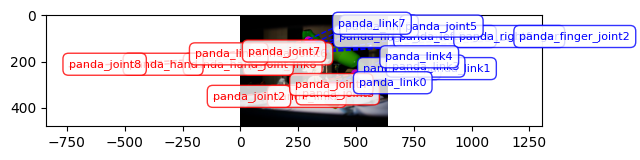

In [27]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
def merge_dict(dict1, dict2):
    return {**dict1, **dict2}
# 假设 annotations 和 img 已经定义
keypoints = annotations['objects'][0]['keypoints']
from lib.dataset.const import KEYPOINT_NAMES, JOINT_NAMES

my_names = ['panda_finger_joint1',
 'panda_joint1',
 'panda_link2',
 'panda_link3',
 'panda_link4',
 'panda_link5',
 'panda_joint6',
 'panda_link7',
 'panda_link8',
 'panda_leftfinger',
 'panda_joint7',
 'panda_hand_joint',
 'panda_rightfinger',
 'panda_hand',
 'panda_finger_joint2',
 'panda_link0',
 'panda_link1',
 'panda_joint2',
 'panda_joint3',
 'panda_joint4',
 'panda_joint5',
 'panda_link6',
 'panda_joint8']
# 筛选关键点
selected_points = []
selected_names = []
for name in my_names:
    for kp in keypoints:
        if kp['name'] == name and 'collision' not in kp['name']:
            selected_points.append(kp['projected_location'])  # 提取 projected_location 的坐标
            selected_names.append(name)  # 提取 name
            break


# 打印筛选后的结果
print("Selected Names:", selected_names)
print("Selected Points:", selected_points)

# 定义距离阈值（根据实际情况调整）
distance_threshold = 30  # 像素距离

# 合并距离非常小的点
def merge_close_points(points, names, threshold):
    merged_points = []
    merged_names = []
    used_indices = set()  # 记录已合并的点的索引

    for i, (x1, y1) in enumerate(points):
        if i in used_indices:
            continue  # 如果点已经合并过，跳过

        # 初始化当前合并组的点和名称
        current_group_points = [(x1, y1)]
        current_group_names = [names[i]]

        # 检查其他点是否与当前点距离小于阈值
        for j, (x2, y2) in enumerate(points):
            if j == i or j in used_indices:
                continue  # 跳过自身和已合并的点

            # 计算两点之间的欧几里得距离
            distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
            if distance < threshold:
                current_group_points.append((x2, y2))
                current_group_names.append(names[j])
                used_indices.add(j)  # 标记为已合并

        # 将当前组合并为一个点（取平均坐标）
        avg_x = np.mean([p[0] for p in current_group_points])
        avg_y = np.mean([p[1] for p in current_group_points])
        merged_points.append((avg_x, avg_y))
        merged_names.append(current_group_names)

    return merged_points, merged_names

# 合并距离非常小的点
merged_points, merged_labels = merge_close_points(selected_points, selected_names, distance_threshold)

# 打印合并后的结果
print("Merged Points:", merged_points)
print("Merged Labels:", merged_labels)

# 绘制图像
fig, ax = plt.subplots(1)
ax.imshow(img)

# 绘制每个 merged_points 的洋红色点和分开的标签
for (x, y), labels in zip(merged_points, merged_labels):
    # 绘制洋红色点
    ax.plot(x, y, 'mo', markersize=5)  # 'mo' 表示洋红色圆点

    # 根据标签数量动态调整标签框位置
    for i, label in enumerate(labels):
        # 设置标注框的偏移量
        offset_x = 130 * (i + 1)  # 水平偏移量，逐渐增加
        offset_y = 60  # 垂直偏移量

        # 交替朝左和朝右
        if i % 2 == 0:
            text_x = x + offset_x  # 朝右
            text_y = y - offset_y
            ax.plot([x, text_x], [y, text_y], color='blue', linestyle='--', linewidth=1)  # 蓝色虚线
            ax.text(text_x, text_y, label, color='blue', fontsize=8, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue', boxstyle='round,pad=0.5'))
        else:
            text_x = x - offset_x  # 朝左

            text_y = y + offset_y
            ax.plot([x, text_x], [y, text_y], color='red', linestyle='--', linewidth=1)  # 蓝色虚线
            ax.text(text_x, text_y, label, color='red', fontsize=8, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', boxstyle='round,pad=0.5'))

        # 绘制连接线（从点到标注框）
        # ax.plot([x, text_x], [y, text_y], color='blue', linestyle='--', linewidth=1)  # 蓝色虚线

        # # 在偏移位置标注 label
        # ax.text(text_x, text_y, label, color='blue', fontsize=8, 
        #         bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue', boxstyle='round,pad=0.5'))  # 动态调整标签框大小

plt.show()

In [5]:
annotations['objects'][0].keys()

dict_keys(['class', 'visibility', 'location', 'quaternion_xyzw', 'pose_transform', 'cuboid_centroid', 'projected_cuboid_centroid', 'bounding_box', 'cuboid', 'projected_cuboid', 'keypoints'])

['panda_link0', 'panda_link2', 'panda_link3', 'panda_link4', 'panda_link6', 'panda_link7', 'panda_hand']


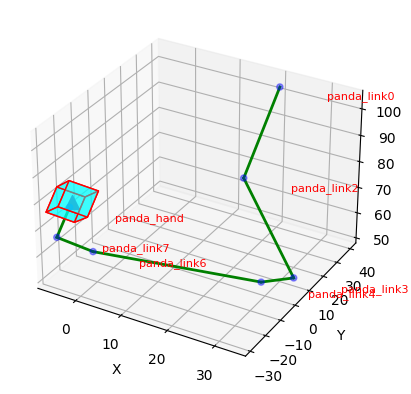

In [6]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
from lib.dataset.const import KEYPOINT_NAMES
# 假设 annotations 已经加载
cuboid = annotations['objects'][0]['cuboid']
keypoints = annotations['objects'][0]['keypoints']
cuboid_centroid = annotations['objects'][0]['cuboid_centroid']

# 根据 KEYPOINT_NAMES 提取对应的 3D 点
selected_points = []
selected_names = []
for name in KEYPOINT_NAMES['panda']:
    for kp in keypoints:
        if kp['name'] == name and 'collision' not in kp['name']:
            selected_points.append(kp['location'])  # 提取 location 的三维坐标
            selected_names.append(name)  # 提取 name
            break
# 创建 3D 绘图
print(selected_names)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

selected_points = np.array(selected_points)
x = selected_points[:, 0]  # 提取 x 坐标
y = selected_points[:, 1]  # 提取 y 坐标
z = selected_points[:, 2]  # 提取 z 坐标

# 绘制三维点
ax.scatter(x, y, z, color='blue', s=20, alpha=0.4)  # 蓝色点

# 顺次连接三维点（只连接上一个点）
for i in range(1, len(selected_points)):
    ax.plot([x[i-1], x[i]], [y[i-1], y[i]], [z[i-1], z[i]], color='green', linestyle='-', linewidth=2)

# 在偏移位置标注 name
# 在偏移位置标注 name
for i, (x_val, y_val, z_val) in enumerate(selected_points):
    name = selected_names[i]  # 提取 name
    offset = 10  # 偏移量
    ax.text(x_val + offset, y_val, z_val, name, color='red', fontsize=8)  # 红色标注

# 将 cuboid 的顶点坐标转换为 numpy 数组
cuboid_vertices = np.array(cuboid)

centroid_x, centroid_y, centroid_z = cuboid_centroid
ax.scatter(centroid_x, centroid_y, centroid_z, color='purple', s=100, label='Cuboid Centroid', marker="^")  
# 定义 cuboid 的面（每个面由 4 个顶点组成）
faces = [
    [cuboid_vertices[0], cuboid_vertices[1], cuboid_vertices[2], cuboid_vertices[3]],  # 底面
    [cuboid_vertices[4], cuboid_vertices[5], cuboid_vertices[6], cuboid_vertices[7]],  # 顶面
    [cuboid_vertices[0], cuboid_vertices[1], cuboid_vertices[5], cuboid_vertices[4]],  # 前面
    [cuboid_vertices[2], cuboid_vertices[3], cuboid_vertices[7], cuboid_vertices[6]],  # 后面
    [cuboid_vertices[0], cuboid_vertices[3], cuboid_vertices[7], cuboid_vertices[4]],  # 左面
    [cuboid_vertices[1], cuboid_vertices[2], cuboid_vertices[6], cuboid_vertices[5]]   # 右面
]

# 绘制 cuboid 的面
ax.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='r', alpha=0.5))

# 设置坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 显示图形
plt.show()

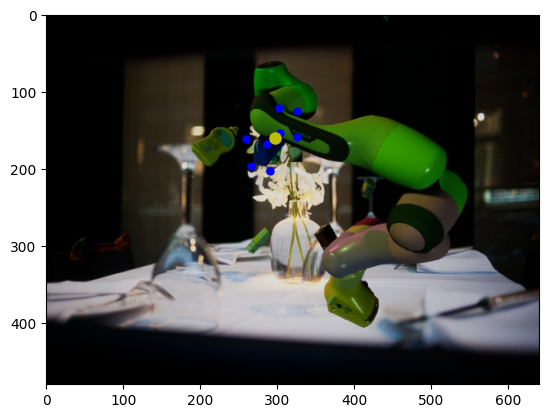

In [7]:
# 提取 bounding_box、projected_cuboid 和 projected_cuboid_centroid
bounding_box = annotations['objects'][0]['bounding_box']
projected_cuboid = annotations['objects'][0]['projected_cuboid']
projected_cuboid_centroid = annotations['objects'][0]['projected_cuboid_centroid']

# 创建绘图
fig, ax = plt.subplots(1)
ax.imshow(img)


# 绘制蓝色点（projected_cuboid）
for point in projected_cuboid:
    x, y = point
    ax.plot(x, y, 'bo', markersize=5)  # 蓝色点

# 绘制绿色点（projected_cuboid_centroid）
centroid_x, centroid_y = projected_cuboid_centroid
ax.plot(centroid_x, centroid_y, 'yo', markersize=8)  # 绿色点

plt.show()

In [8]:
annotations['camera_data']

{'location_worldframe': [-12.450300216674805,
  -50.0724983215332,
  139.7021026611328],
 'quaternion_xyzw_worldframe': [-0.1655000001192093,
  0.3328999876976013,
  0.4133000075817108,
  0.8312000036239624]}

In [9]:
annotations['objects'][0]['pose_transform']

[[-0.7972999811172485, -0.41659998893737793, 0.4366999864578247, 0],
 [0.603600025177002, -0.5503000020980835, 0.5769000053405762, 0],
 [0, -0.7235999703407288, -0.6901999711990356, 0],
 [20.296199798583984, 39.398399353027344, 103.14360046386719, 1]]

In [10]:
from lib.utils.geometries import (
    angle_axis_to_rotation_matrix, compute_geodesic_distance_from_two_matrices,
    quat_to_rotmat, rot6d_to_rotmat, rotmat_to_quat, rotmat_to_rot6d)
annotations['objects'][0]["location"], annotations['objects'][0]['quaternion_xyzw']

([20.296199798583984, 39.398399353027344, 103.14360046386719],
 [0.3328999876976013,
  -0.4133000075817108,
  -0.1655000001192093,
  0.8312000036239624])

In [11]:
import numpy as np

def myquat_to_rotmat(quat):
    """
    将四元数转换为旋转矩阵。
    Args:
        quat: 四元数，形状为 [4] 或 [B, 4]。
    Returns:
        旋转矩阵，形状为 [3, 3] 或 [B, 3, 3]。
    """
    # 确保 quat 的形状为 [B, 4]
    quat = np.array(quat)
    if quat.ndim == 1:
        quat = quat[np.newaxis, :]  # 如果输入是 [4]，扩展为 [1, 4]
    
    # 归一化四元数
    norm_quat = quat / np.linalg.norm(quat, axis=-1, keepdims=True)
    
    # 提取四元数的分量
    w, x, y, z = norm_quat[:, 0], norm_quat[:, 1], norm_quat[:, 2], norm_quat[:, 3]
    
    # 计算中间变量
    w2, x2, y2, z2 = w**2, x**2, y**2, z**2
    wx, wy, wz = w * x, w * y, w * z
    xy, xz, yz = x * y, x * z, y * z
    
    # 构造旋转矩阵
    rotMat = np.stack([
        w2 + x2 - y2 - z2, 2 * xy - 2 * wz, 2 * wy + 2 * xz,
        2 * wz + 2 * xy, w2 - x2 + y2 - z2, 2 * yz - 2 * wx,
        2 * xz - 2 * wy, 2 * wx + 2 * yz, w2 - x2 - y2 + z2
    ], axis=-1).reshape(-1, 3, 3)
    
    return rotMat.squeeze()  # 如果输入是单个四元数，去掉多余的维度
quat_rotmat = myquat_to_rotmat(annotations['objects'][0]['quaternion_xyzw'])
fixed_transform = np.array([
				[ 0, 0, 1],
				[ -1, 0, 0],
				[ 0, -1, 0]])
quat_rotmat, np.array(annotations['objects'][0]['pose_transform'])[:3, :3]

(array([[-4.36678025e-01, -4.16642723e-01, -7.97321230e-01],
        [ 6.90268399e-01, -7.23553408e-01,  4.79371725e-05],
        [-5.76924466e-01, -5.50344716e-01,  6.03555179e-01]]),
 array([[-0.79729998, -0.41659999,  0.43669999],
        [ 0.60360003, -0.5503    ,  0.57690001],
        [ 0.        , -0.72359997, -0.69019997]]))

In [12]:
with open(os.path.join(data_dir, '_camera_settings.json'), 'r') as f:
    camera_settings = json.load(f)

cuboid = annotations['objects'][0]['cuboid']
projected_cuboid = annotations['objects'][0]['projected_cuboid']
keypoints = annotations['objects'][0]['keypoints']
cuboid_centroid = annotations['objects'][0]['cuboid_centroid']
projected_cuboid_centroid = annotations['objects'][0]['projected_cuboid_centroid']

translation = annotations["objects"][0]['location']
rotation_xyzw = annotations["objects"][0]['quaternion_xyzw']
pose_transform = annotations["objects"][0]['pose_transform']
camera_location_worldframe = annotations["camera_data"]["location_worldframe"]
camera_rotation_xyzw_worldframe = annotations["camera_data"]["quaternion_xyzw_worldframe"]

# 根据 KEYPOINT_NAMES 提取对应的 3D 点
selected_points = []
selected_projected_points = []
selected_names = []
for name in KEYPOINT_NAMES['panda']:
    for kp in keypoints:
        if kp['name'] == name and 'collision' not in kp['name']:
            selected_points.append(kp['location'])  # 提取 location 的三维坐标
            selected_projected_points.append(kp['projected_location'])
            selected_names.append(name)  

fx, fy, cx, cy = camera_settings['camera_settings'][0]['intrinsic_settings']['fx'], \
                    camera_settings['camera_settings'][0]['intrinsic_settings']['fy'], \
                    camera_settings['camera_settings'][0]['intrinsic_settings']['cx'], \
                    camera_settings['camera_settings'][0]['intrinsic_settings']['cy']

K =  np.array([[fx, 0, cx],
               [0, fy, cy],
               [0, 0, 1]])
print(f"K is {K}")
print(f"translation is {translation}")
print(f"rotation_xyzw is {rotation_xyzw}")
print(f"camera_location_worldframe is {camera_location_worldframe}")
print(f"camera_rotation_xyzw_worldframe is {camera_rotation_xyzw_worldframe}")
print(f"pose_transform is {pose_transform}")

print(f"3D point is {cuboid_centroid}")
print(f"2D projected point is {projected_cuboid_centroid}")


K is [[320   0 320]
 [  0 320 240]
 [  0   0   1]]
translation is [20.296199798583984, 39.398399353027344, 103.14360046386719]
rotation_xyzw is [0.3328999876976013, -0.4133000075817108, -0.1655000001192093, 0.8312000036239624]
camera_location_worldframe is [-12.450300216674805, -50.0724983215332, 139.7021026611328]
camera_rotation_xyzw_worldframe is [-0.1655000001192093, 0.3328999876976013, 0.4133000075817108, 0.8312000036239624]
pose_transform is [[-0.7972999811172485, -0.41659998893737793, 0.4366999864578247, 0], [0.603600025177002, -0.5503000020980835, 0.5769000053405762, 0], [0, -0.7235999703407288, -0.6901999711990356, 0], [20.296199798583984, 39.398399353027344, 103.14360046386719, 1]]
3D point is [-5.600599765777588, -18.997299194335938, 75.48780059814453]
2D projected point is [296.2583923339844, 159.4683074951172]


In [13]:
import numpy as np
import json
from scipy.spatial.transform import Rotation as R

# 假设已加载的文件和数据
# 这里直接从你给出的数据提取所需变量
translation = annotations["objects"][0]['location']
rotation_xyzw = annotations["objects"][0]['quaternion_xyzw']
camera_location_worldframe = annotations["camera_data"]["location_worldframe"]
camera_rotation_xyzw_worldframe = annotations["camera_data"]["quaternion_xyzw_worldframe"]
cuboid_centroid = annotations['objects'][0]['cuboid_centroid']
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0, 0, 1]])

# 1. 先将四元数转换为旋转矩阵
rotation_matrix_object_to_world = R.from_quat(rotation_xyzw).as_matrix()
rotation_matrix_camera_to_world = R.from_quat(camera_rotation_xyzw_worldframe).as_matrix()

# 2. 计算物体的3D点相对于世界坐标系的位置
cuboid_centroid_offset = np.array(cuboid_centroid) - np.array(translation)
rotated_point_world = np.dot(rotation_matrix_object_to_world, cuboid_centroid_offset)
world_point = rotated_point_world + np.array(camera_location_worldframe)

# 3. 将世界坐标系中的点转换到相机坐标系
rotated_point_camera = np.dot(rotation_matrix_camera_to_world, world_point - np.array(camera_location_worldframe))

# 4. 计算投影
# 为了透视投影，我们需要将相机坐标系中的3D点转化为2D
point_3d_homogeneous = rotated_point_camera  # 同次坐标
point_2d_homogeneous = np.dot(K, point_3d_homogeneous)  # 相机投影

# 最后进行归一化，得到2D坐标
projected_point_2d = point_2d_homogeneous[:2] / point_2d_homogeneous[2]

# 输出结果
print(f"Transformed 3D point in camera coordinates: {rotated_point_camera}")
print(f"Projected 2D point: {projected_point_2d}")


Transformed 3D point in camera coordinates: [-12.10798337 -43.29191011 -53.14839942]
Projected 2D point: [392.90068413 500.65528572]
